In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px

from google.colab import drive
drive.mount('/content/gdrive')

%cd gdrive/MyDrive/ITMO_HW/

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
[Errno 2] No such file or directory: 'gdrive/MyDrive/ITMO_HW/'
/content/gdrive/MyDrive/ITMO_HW


In [2]:
#считываем файл в датафрейм
df = pd.read_csv('train.csv')

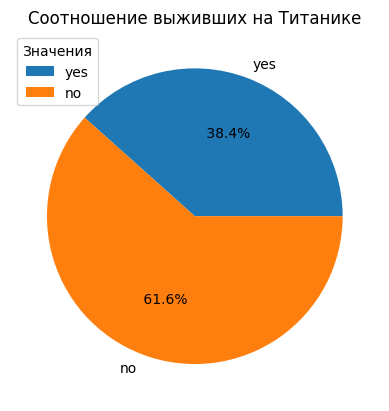

In [74]:
#survived
labels= ['yes', 'no']
value = [df['Survived'].value_counts()[1], df['Survived'].value_counts()[0]]
plt.pie(value, labels=labels, autopct= ' %1.1f%%')
plt.title("Соотношение выживших на Титанике")
plt.legend(title="Значения", loc="upper left")
plt.show()

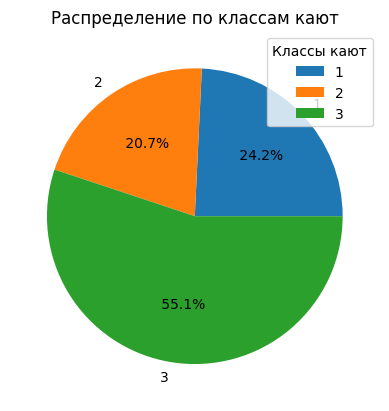

In [77]:
#Pclass
labels= ['1', '2', '3']
value = [df['Pclass'].value_counts()[1], df['Pclass'].value_counts()[2], df['Pclass'].value_counts()[3]]
plt.pie(value, labels=labels, autopct= ' %1.1f%%')
plt.title("Распределение по классам кают")
plt.legend(title="Классы кают", loc="upper right")
plt.show()

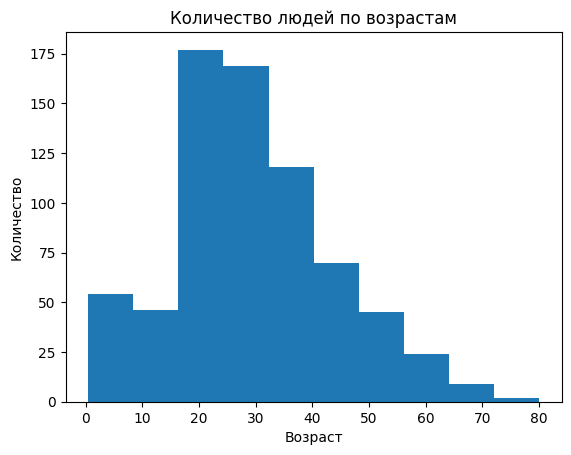

In [79]:
#Age
plt.hist(df['Age'])
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.title('Количество людей по возрастам')
plt.show()


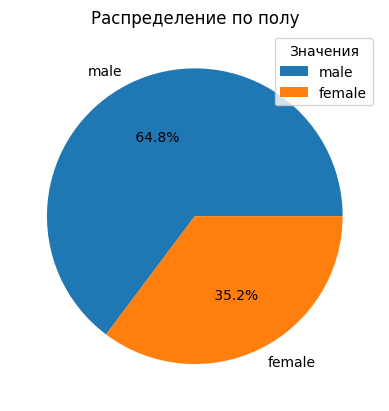

In [81]:
#Sex
labels= ['male', 'female']
value = [df['Sex'].value_counts()["male"], df['Sex'].value_counts()["female"]]
plt.pie(value, labels=labels, autopct= ' %1.1f%%')
plt.title("Распределение по полу")
plt.legend(title="Значения", loc="upper right")
plt.show()

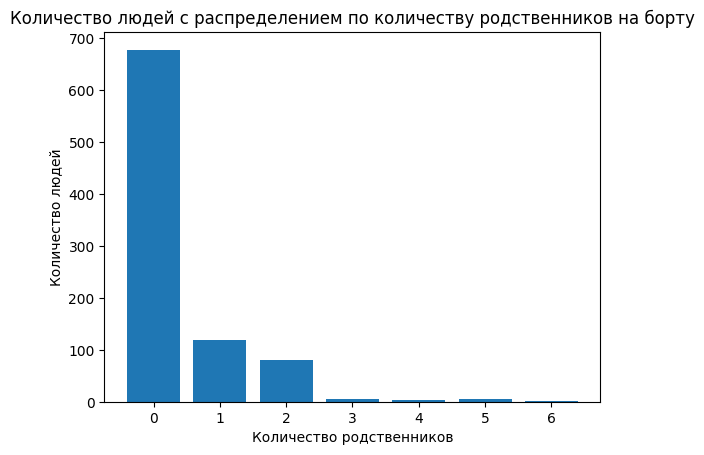

In [84]:
#Parch
x = df['Parch'].value_counts().index
y = df['Parch'].value_counts().values
plt.bar(x=x, height=y)
plt.xlabel('Количество родственников')
plt.ylabel('Количество людей')
plt.title('Количество людей с распределением по количеству родственников на борту')
plt.show()

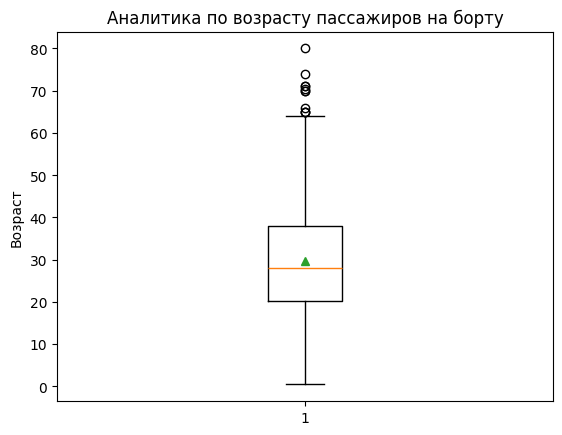

In [94]:
#Постройте график типа boxplot для столбца Age
#с NaN выдаёт некорректный график, не учитываем их
#-
# половина всех значений сосредоточена в диапазоне примерно 20-40 лет
# медианное значение около 30 лет
# выше максимума (не фактического, рассчитанного по формуле) присутствует несколько выбросов данных

plt.boxplot(df['Age'].dropna(), showmeans=True)
plt.title('Аналитика по возрасту пассажиров на борту')
plt.ylabel('Возраст')
plt.show()

In [38]:
#смотрим значения столбцов, чтобы отобрать только числовые для построения далее pairplot
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


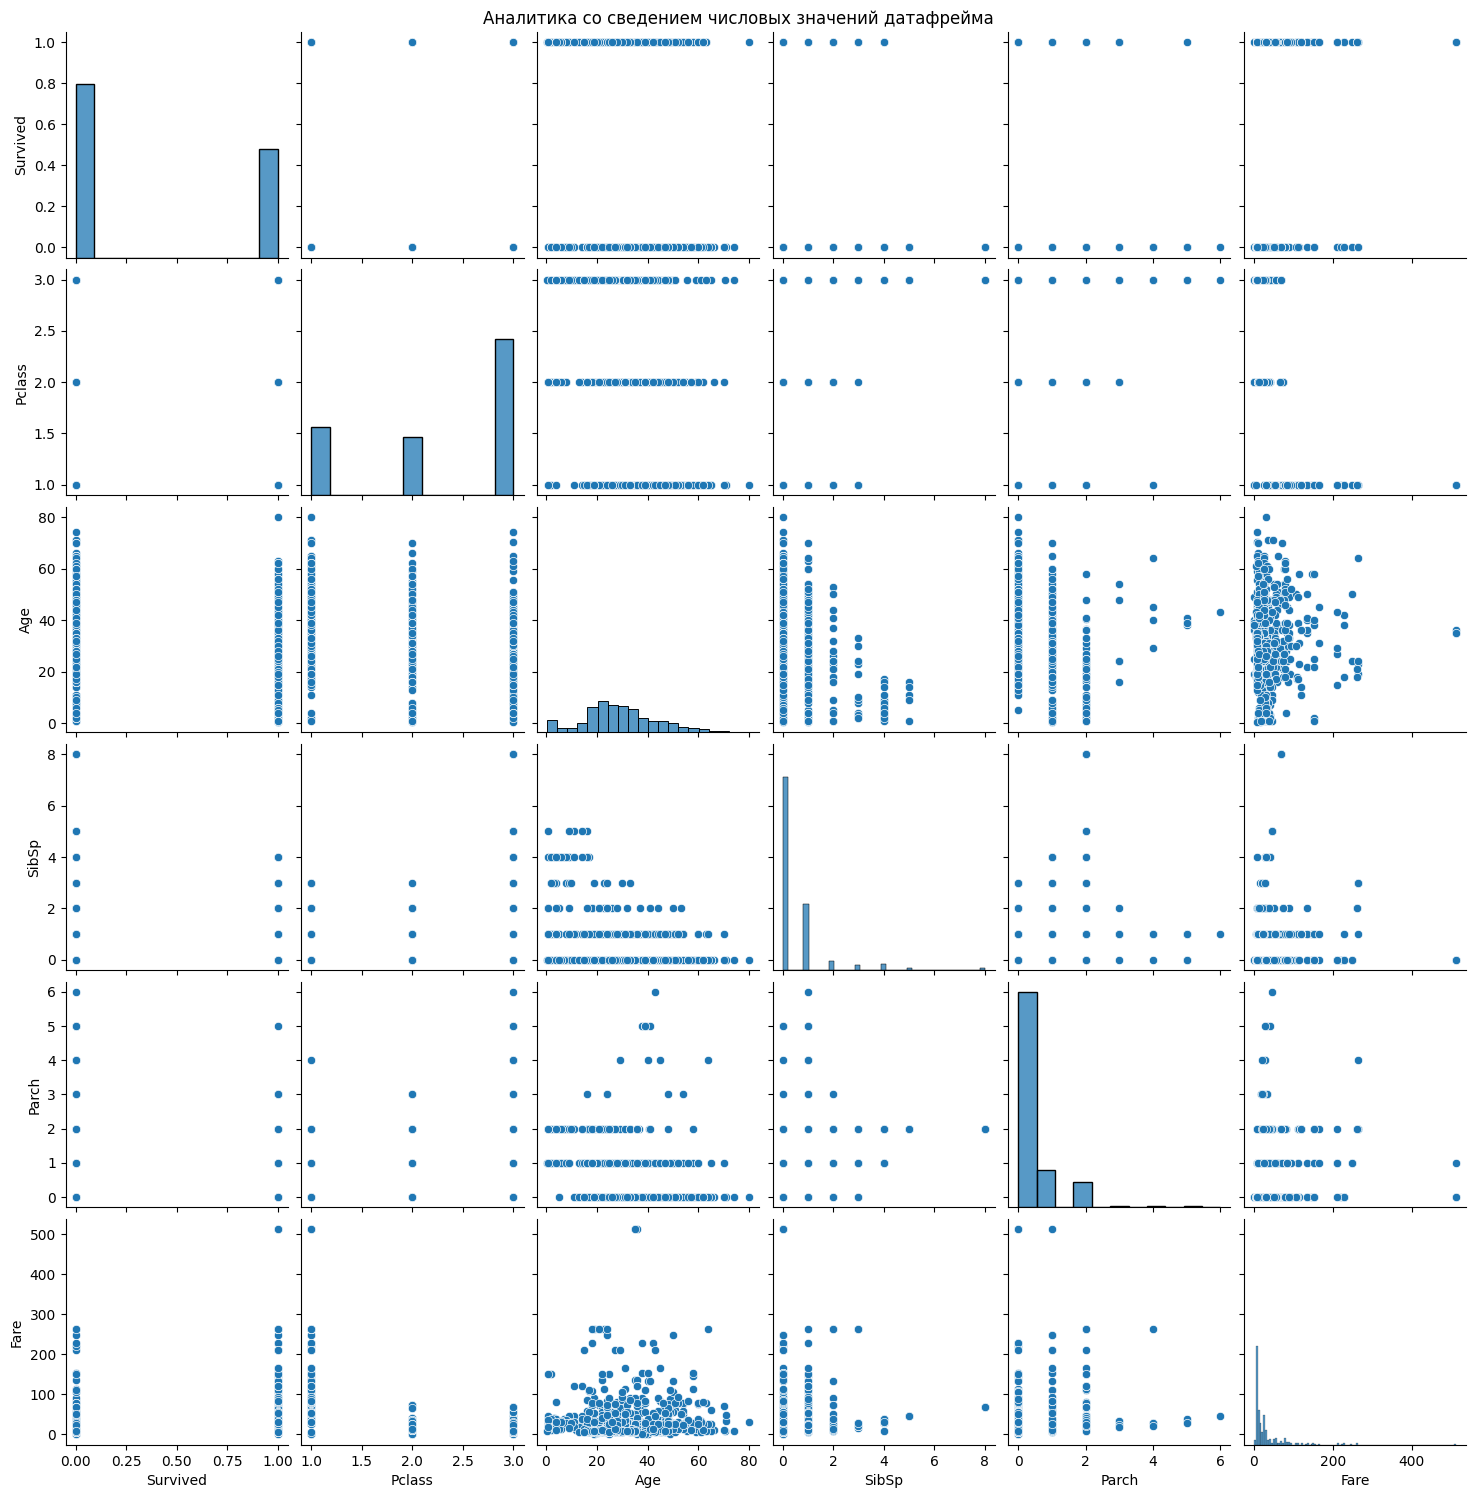

In [103]:
#Постройте график типа pairplot для всех числовых переменных датасета
#берём числовые (int64 и float64) столбцы из предыдущего блока, но не берём PassengerId, т.к. он уникальный для каждой строки
sns.pairplot(df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]])
plt.suptitle('Аналитика со сведением числовых значений датафрейма', y=1)
plt.show()

In [53]:
#Постройте интерактивный sunburst plot (визуализация иерархических данных) с помощью plotly.
#На первом уровне иерархии - количество пассажиров в каждом из классов, а на втором количество женщин/мужчин в этом классе
fig = px.sunburst(df, path=['Pclass', 'Sex'], title='Количество женщин и мужчин в разрезе по классам кают')
fig.show()
